In [1]:
import os 
import sys

sys.path.append(os.path.dirname(os.getcwd()))

from env_constants import (
    PYGARMENT_ROOT, SEAMDRESS_SEWFACTORY_DIR, CLO_AUTO_GEN_DIR
)

sys.path.append(PYGARMENT_ROOT)
import pygarment as pyg

from sewing_pattern import (
    Stitch, StitchDict, SVGPanel, SewingPattern,
    ParameterizedSeamLine, ParameterizedEdgeLine,
    UnconstrainedFewViewLabel
)

In [2]:
import numpy as np
from dataclasses import dataclass

@dataclass
class CloCamera :
    name: str = None
    cam2world: np.ndarray = None
    fov: float = None
    width: int = None
    height: int = None
    
    
    # name: str = None
    # dist: float = None
    # hor: float = None
    # ver: float = None
    # fov: float = None
    # width: int = None
    # height: int = None
    
    # x: float = None
    # y: float = None
    # z: float = None
    
    # def spherical_to_cartesian(self) :
    #     self.y = np.abs(self.dist) * np.cos(np.deg2rad(self.ver))
    #     self.x = np.abs(self.dist) * np.sin(np.deg2rad(self.ver)) * np.cos(np.deg2rad(self.hor))
    #     self.z = np.abs(self.dist) * np.sin(np.deg2rad(self.ver)) * np.sin(np.deg2rad(self.hor))
    
camera_info = {
    "Custom_View_1": CloCamera(
        name = "Custom_View_1",
        cam2world = np.array([
            [1, 0, 0, -9.2e-05],
            [0, 1, 0, -896.122],
            [0, 0, 1, -7998.56],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),  
    "Custom_View_2": CloCamera(
        name = "Custom_View_2",
        cam2world = np.array([
            [0.707107, 0, 0.707107, 1.01581],
            [0, 1, 0, -896.122],
            [-0.707107, 0, 0.707107, -7998.98],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_3": CloCamera(
        name = "Custom_View_3",
        cam2world = np.array([
            [0.707107, 0, -0.707107, -1.01581],
            [0, 1, 0, -896.122],
            [0.707107, 0, 0.707107, -7998.98],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_4": CloCamera(
        name = "Custom_View_4",
        cam2world = np.array([
            [0, 0, 1, 1.44049],
            [0, 1, 0, -896.122],
            [-1, 0, 0, -8000],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_5": CloCamera(
        name = "Custom_View_5",
        cam2world = np.array([
            [0, 0, -1, -1.44093],
            [0, 1, 0, -896.122],
            [1, 0, 0, -8000],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_6": CloCamera(
        name = "Custom_View_6",
        cam2world = np.array([
            [-1, 0, 0, -0.000608],
            [0, 1, 0, -896.122],
            [0, 0, -1, -8001.44],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_7": CloCamera(
        name = "Custom_View_7",
        cam2world = np.array([
            [-0.677822, 0, -0.735226, -1.0604],
            [-0.051424, 0.997551, 0.047409, -893.857],
            [0.733425, 0.069943, -0.676162, -8063.65],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_8": CloCamera(
        name = "Custom_View_8",
        cam2world = np.array([
            [-0.773786, 0, 0.633447, 0.911345],
            [0.035455, 0.998432, 0.043309, -894.654],
            [-0.632454, 0.055971, -0.772573, -8051.27],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_9": CloCamera(
        name = "Custom_View_9",
        cam2world = np.array([
            [0.847255, 0, 0.531186, 0.765239],
            [0.223366, 0.907291, -0.356274, -813.553],
            [-0.48194, 0.420503, 0.768707, -8375.71],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_10": CloCamera(
        name = "Custom_View_10",
        cam2world = np.array([
            [0.716937, 0, -0.697138, -1.0054],
            [-0.275326, 0.918708, -0.283145, -823.685],
            [0.640466, 0.394938, 0.658656, -8352.96],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    )   
}
for camera in camera_info.values() :
    camera.cam2world = np.linalg.inv(camera.cam2world)




In [3]:
import os
from glob import glob
from pathlib import Path
import json

import trimesh
import xml.etree.ElementTree as ET

from analysis_utils import visualize_meshes_plotly

@dataclass
class SeamDressScene :
    base_path: str = None
    
    spec_path_list: list = None
    stitch_dict_list: list = None
    
    pose_list: list = None
    mesh_path_list: list = None
    meta_path_list: list = None
    mesh_list: list = None
    
    rendered_path_list: list = None
    view_list: list = None

    def __post_init__(self, garment_id_version = "01"):
        self.garment_id_list = str(Path(self.base_path).name).split("__")[::2]
        self.spec_path_list = list(map(
            lambda gid : str(Path(self.base_path) / f"{gid}__{garment_id_version}__specification.json"),
            self.garment_id_list,
        ))
        if len(list(filter(os.path.exists, self.spec_path_list))) == 0 :
            self.spec_path_list = list(map(
                lambda gid : str(Path(self.base_path) / f"{gid}_specification.json"),
                self.garment_id_list,
            ))
        
        self.stitch_dict_list = []
        for spec_path in self.spec_path_list:
            with open(spec_path, "r") as f:
                spec = json.load(f)
            stitch_dict = {}
            for idx, stitch in enumerate(spec["pattern"]["stitches"]):
                stitch_dict[idx] = stitch
            self.stitch_dict_list.append(stitch_dict)
            
        self.stitch_dict_dict = {}
        for garment_id, spec_path in zip(self.garment_id_list, self.spec_path_list) :
            with open(spec_path, "r") as f :
                spec = json.load(f)
            stitch_dict = {}
            for idx, stitch in enumerate(spec["pattern"]["stitches"]) :
                stitch_dict[idx] = stitch
            self.stitch_dict_dict[garment_id] = stitch_dict
        
        self.garment_count = len(self.spec_path_list)
        
        self.mesh_path_list = sorted(glob(str(Path(self.base_path)/"*.obj")))
        self.pose_list = list(map(lambda x: Path(x).stem, self.mesh_path_list))
        self.meta_path_list = list(map(
            lambda x : str(Path(self.base_path) / f"{x}_meta_data.xml"),
            self.pose_list
        ))
        
        self.rendered_path_list = list(filter(
            lambda x : "__" in Path(x).stem and Path(x).stem[:2] != "WB",
            glob(str(Path(self.base_path) / "*.png"))
        ))
        self.rendered_path_list = sorted(self.rendered_path_list, key=lambda x: int(Path(x).stem.split("_")[-2]))
        self.view_list = list(map(lambda x: Path(x).stem, self.rendered_path_list))
        
    def read_mesh(self):
        self.mesh_scene_list = list(map(
            lambda x: trimesh.load(x),
            self.mesh_path_list
        ))
        # self.mesh_dict = dict(zip(self.pose_list, self.mesh_list))
        
        # key : pose name, value : body mesh
        self.body_mesh_dict = {}
        self.garment_mesh_dict_dict = {}
        for pose_name, mesh_scene in zip(self.pose_list, self.mesh_scene_list) :
            mesh_list = []
            for geometry in mesh_scene.geometry.values() :
                if isinstance(geometry, trimesh.Trimesh):
                    mesh_list.append(geometry)
            self.body_mesh_dict[pose_name] = trimesh.util.concatenate(mesh_list[:-self.garment_count])
            self.garment_mesh_dict_dict[pose_name] = dict(zip(
                self.garment_id_list,
                mesh_list[-1:-self.garment_count-1:-1]
            ))
        
        self._get_stitch_vert()
        
    def _get_stitch_vert(self) :
        """
        Set below member variables.
        - self.stitch_vert_mask_dict_list
            - list for each garment, dict containing stitch vertex mask for each stitch
        - self.stitch_vert_idx_arr_list
        - self.stitch_vert_idx_arr_dict_list
        """
        
        # CLO saved metatdata does not distinguish stitches between garments
        raw_stitch_vert_idx_list_list = []
        
        tree = ET.parse(self.meta_path_list[0])
        root = tree.getroot()
        seam_line_pair_list = root.find("SeamLinePairList")
        for pair in seam_line_pair_list.findall("SeamLinePair") :
            seam_lines = pair.findall("SeamLine")
            if len(seam_lines) >= 2 :
                first_indexes_str = seam_lines[0].get("MeshPointIndexes")
                second_indexes_str = seam_lines[1].get("MeshPointIndexes")
                first_list = list(map(lambda x: int(x)-1, first_indexes_str.split("/")))
                second_list = list(map(lambda x: int(x)-1, second_indexes_str.split("/")))
                raw_stitch_vert_idx_list_list.append(first_list + second_list)
            else :
                print("SeamLinePair has less than 2 SeamLine")
        
        stitch_vert_idx_arr_list_dict = {}
        stitch_idx_accum = 0
        vert_count_accum = 0
        for (garment_id, stitch_dict) in self.stitch_dict_dict.items() :
            garment_mesh = list(self.garment_mesh_dict_dict.values())[0][garment_id]
            vert_count = garment_mesh.vertices.shape[0]
            
            stitch_vert_idx_arr_list = []
            for _ in stitch_dict.keys() :
                stitch_vert_idx_arr_list.append(
                    list(map(
                        lambda x: x-vert_count_accum,
                        raw_stitch_vert_idx_list_list[stitch_idx_accum]
                    ))
                )
                stitch_idx_accum += 1
            stitch_vert_idx_arr_list_dict[garment_id] = stitch_vert_idx_arr_list
            vert_count_accum += vert_count
        
        self.stitch_vert_idx_arr_list_dict = stitch_vert_idx_arr_list_dict
        
        self.stitch_vert_mask_dict_dict = {}
        for (garment_id, stitch_vert_idx_arr_list) in stitch_vert_idx_arr_list_dict.items() :
            garment_mesh = list(self.garment_mesh_dict_dict.values())[0][garment_id]
            vert_count = garment_mesh.vertices.shape[0]
            
            self.stitch_vert_mask_dict_dict[garment_id] = {}
            for (stitch_idx, stitch_vert_idx_arr) in enumerate(stitch_vert_idx_arr_list) :
                self.stitch_vert_mask_dict_dict[garment_id][stitch_idx] = np.zeros(
                    vert_count, dtype=bool
                )
                self.stitch_vert_mask_dict_dict[garment_id][stitch_idx][stitch_vert_idx_arr] = True
        
        # dict per garment, dict per stitch, array of seam line vertex idx, ordered so that it follows seam line linearly
        # vertex idx is already sorted linearly. just need to remove overlapping vertices
        # In the case of stitch between two garments, every seam vertex is duplicated,
        self.seam_line_vert_idx_arr_dict_dict = {}
        for garment_id, stitch_vert_idx_arr_list in stitch_vert_idx_arr_list_dict.items() :
            self.seam_line_vert_idx_arr_dict_dict[garment_id] = {}
            
            garment_mesh = list(self.garment_mesh_dict_dict.values())[0][garment_id]
            vert_count = garment_mesh.vertices.shape[0]
            
            for stch_idx, stch_vert_idx_arr in enumerate(stitch_vert_idx_arr_list) :
                seam_line_vert_idx_list = []
                for vert_idx in stch_vert_idx_arr :
                    
                    for i in seam_line_vert_idx_list :
                        if (garment_mesh.vertices[vert_idx] == garment_mesh.vertices[i]).all() :
                            break
                    else :
                        seam_line_vert_idx_list.append(vert_idx)

                self.seam_line_vert_idx_arr_dict_dict[garment_id][stch_idx] = np.array(seam_line_vert_idx_list)

[Line(start=(-54.7448-1465.06j), end=(-54.7448-838.648j)), CubicBezier(start=(-54.7448-838.648j), control1=(-54.7448-765.201j), control2=(-51.5242-692.01j), end=(-64.1571-619.076j)), Line(start=(-64.1571-619.076j), end=(-134.807-619.076j)), Line(start=(-134.807-619.076j), end=(-155.083-776.717j)), Line(start=(-155.083-776.717j), end=(-167.014-619.076j)), Line(start=(-167.014-619.076j), end=(-205.762-619.076j)), Line(start=(-205.762-619.076j), end=(-217.693-794.328j)), Line(start=(-217.693-794.328j), end=(-229.624-619.076j)), Line(start=(-229.624-619.076j), end=(-287.746-619.076j)), Line(start=(-287.746-619.076j), end=(-287.746-658.776j)), CubicBezier(start=(-287.746-658.776j), control1=(-273.489-849.437j), control2=(-308.664-913.564j), end=(-350.502-913.564j)), CubicBezier(start=(-350.502-913.564j), control1=(-339.169-1023.62j), control2=(-333.463-1198.29j), end=(-333.463-1455.9j)), Line(start=(-333.463-1455.9j), end=(-54.7448-1465.06j))]
[Line(start=(308.088-1336.48j), end=(550.556-13

In [9]:
import os
from glob import glob
from pathlib import Path
from dataclasses import dataclass
import json


import random
import numpy as np
import matplotlib.pyplot as plt

import plotly.graph_objects as go

from analysis_utils import visualize_meshes_plotly, visualize_camera_info




garment_path_list = sorted(glob("../sample_data/*"))
garment_path_list = sorted(glob("../sample_data_deprecated/*"))

garment_path_list

[]

In [5]:
import os
from pathlib import Path
from datetime import datetime

def get_dir_mtime(dir_path):
    """Get the last modified time of a directory and its contents."""
    try:
        # Get the directory's own modification time
        dir_mtime = os.path.getmtime(dir_path)
        
        # Get the latest modification time of all files in the directory
        for root, _, files in os.walk(dir_path):
            for file in files:
                file_path = os.path.join(root, file)
                try:
                    file_mtime = os.path.getmtime(file_path)
                    dir_mtime = max(dir_mtime, file_mtime)
                except (OSError, FileNotFoundError):
                    continue
                    
        return dir_mtime
    except (OSError, FileNotFoundError):
        return 0

def sort_directories_by_mtime(directory_path, reverse=True):
    """
    Sort subdirectories by their last modified time.
    
    Args:
        directory_path (str): Path to the parent directory
        reverse (bool): If True, sort in descending order (newest first)
        
    Returns:
        list: List of tuples containing (directory_name, last_modified_time)
    """
    if not os.path.isdir(directory_path):
        raise ValueError(f"Directory does not exist: {directory_path}")
    
    # Get all subdirectories
    subdirs = [d for d in os.listdir(directory_path) 
              if os.path.isdir(os.path.join(directory_path, d))]
    
    # Create list of (directory_name, mtime) tuples
    dirs_with_mtime = []
    for dir_name in subdirs:
        full_path = os.path.join(directory_path, dir_name)
        mtime = get_dir_mtime(full_path)
        dirs_with_mtime.append((dir_name, mtime))
    
    # Sort by modification time
    sorted_dirs = sorted(dirs_with_mtime, 
                        key=lambda x: x[1], 
                        reverse=reverse)
    
    return sorted_dirs


In [6]:
# COUNT = 100

# seamdress_sewfactory_path_list = sort_directories_by_mtime(
#     os.path.join(SEAMDRESS_SEWFACTORY_DIR, "sewfactory__01")
# )

# garment_path_list = list(map(
#     lambda dir_path_mtime : os.path.join(
#         SEAMDRESS_SEWFACTORY_DIR, "sewfactory__01", dir_path_mtime[0]),
#     seamdress_sewfactory_path_list[:COUNT]
# ))

# garment_path_list


garment_path_list = list(map(
    lambda x : os.path.join(CLO_AUTO_GEN_DIR, "sample_data", x),
    os.listdir(os.path.join(CLO_AUTO_GEN_DIR, "sample_data"))
))

In [7]:
# Handle Multiple Garment Case


IDX = 16
IDX = 17
IDX = 4
IDX = 2

scene = SeamDressScene(base_path=Path(garment_path_list[IDX]))

# print(scene.base_path)
# print(scene.pose_list)
# print(scene.mesh_path_list)
# print(scene.view_list)

# str(Path(scene.base_path).name).split("__")[::2]
# str(Path(scene.base_path).name).split("__")[1::2]

# print(scene.spec_path_list)
# list(map(
#     lambda x : os.path.exists(x),
#     scene.spec_path_list
# ))

scene.read_mesh()


/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/wb_dress_sleeveless_H097SG0SIZ__01/Dynamic__Custom_View_1_1.png


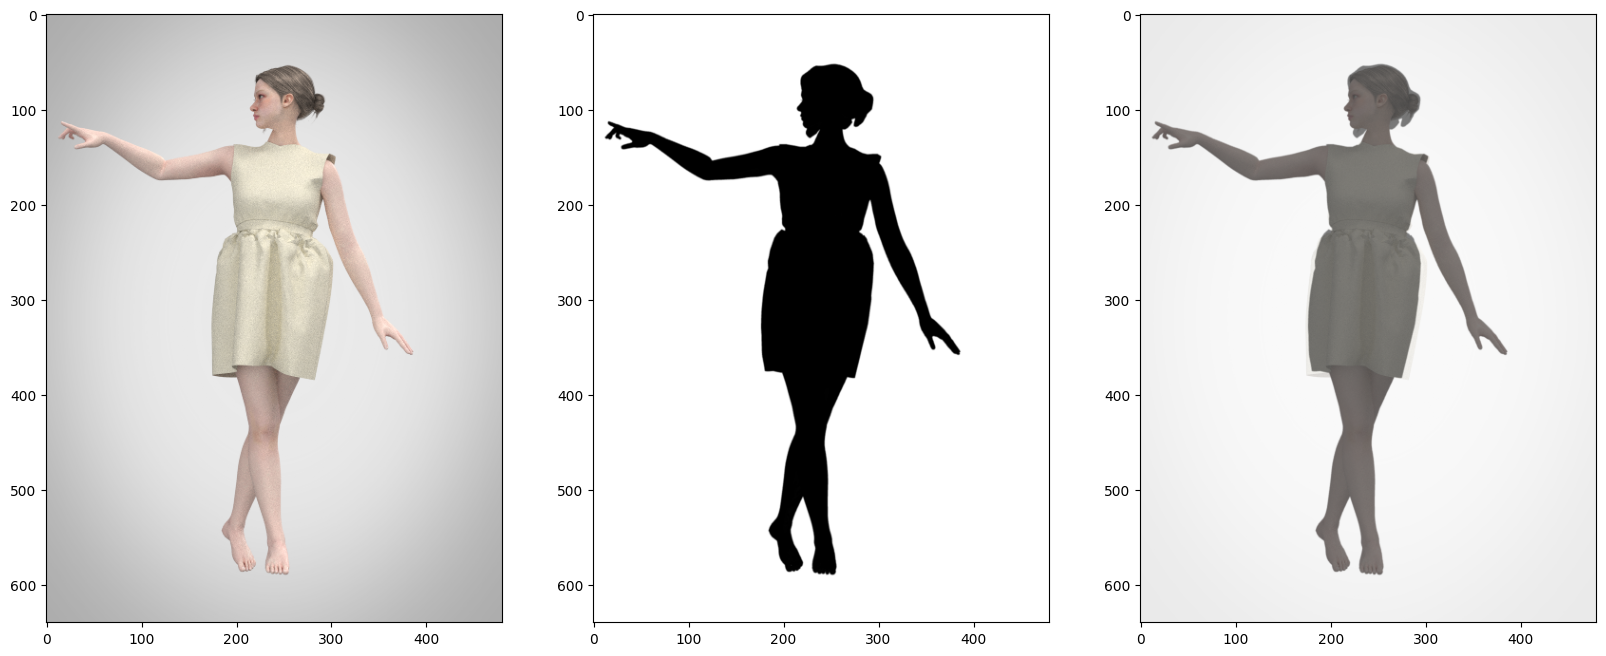

0 wb_dress_sleeveless_H097SG0SIZ


/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/wb_dress_sleeveless_H097SG0SIZ__01/FV2_07__Custom_View_2_1.png


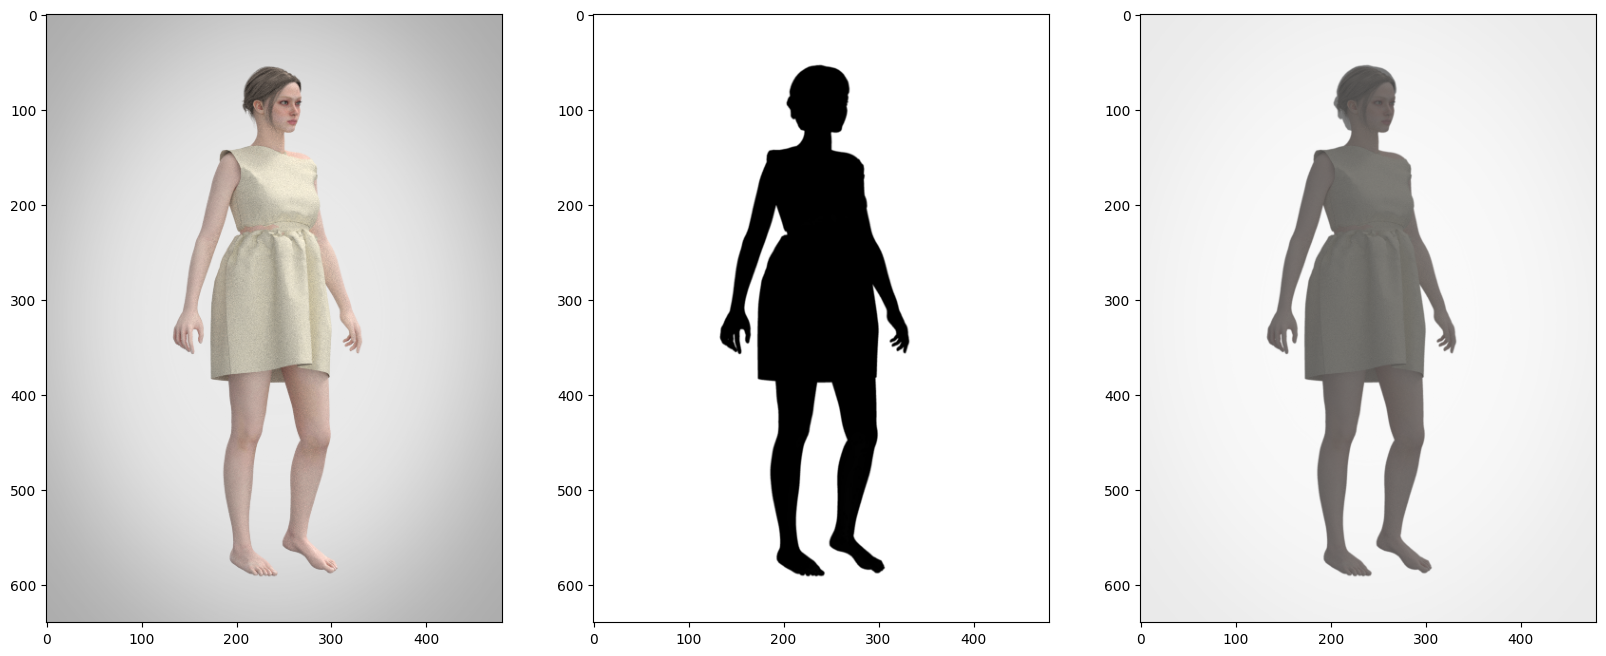

0 wb_dress_sleeveless_H097SG0SIZ


/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/wb_dress_sleeveless_H097SG0SIZ__01/FV2_05__Custom_View_3_1.png


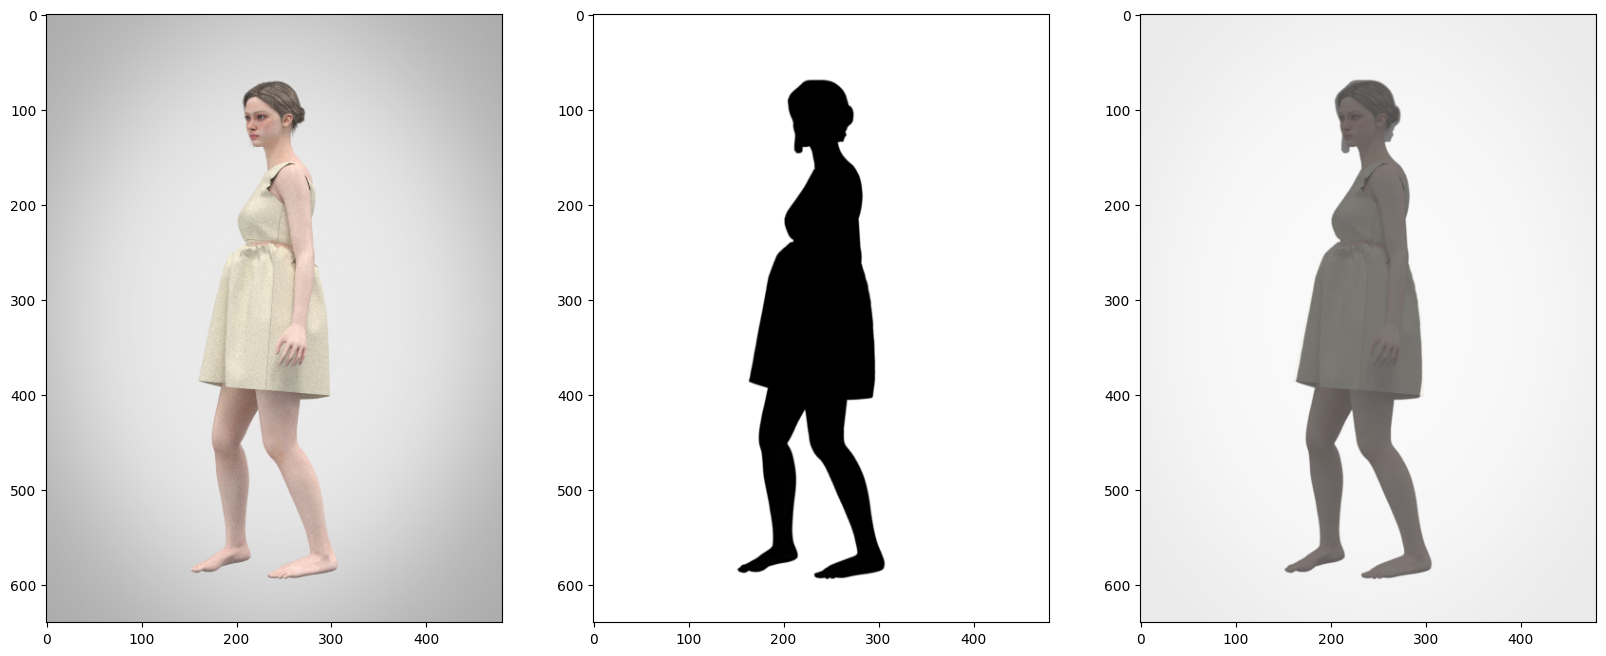

0 wb_dress_sleeveless_H097SG0SIZ


/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/wb_dress_sleeveless_H097SG0SIZ__01/random__Custom_View_4_1.png


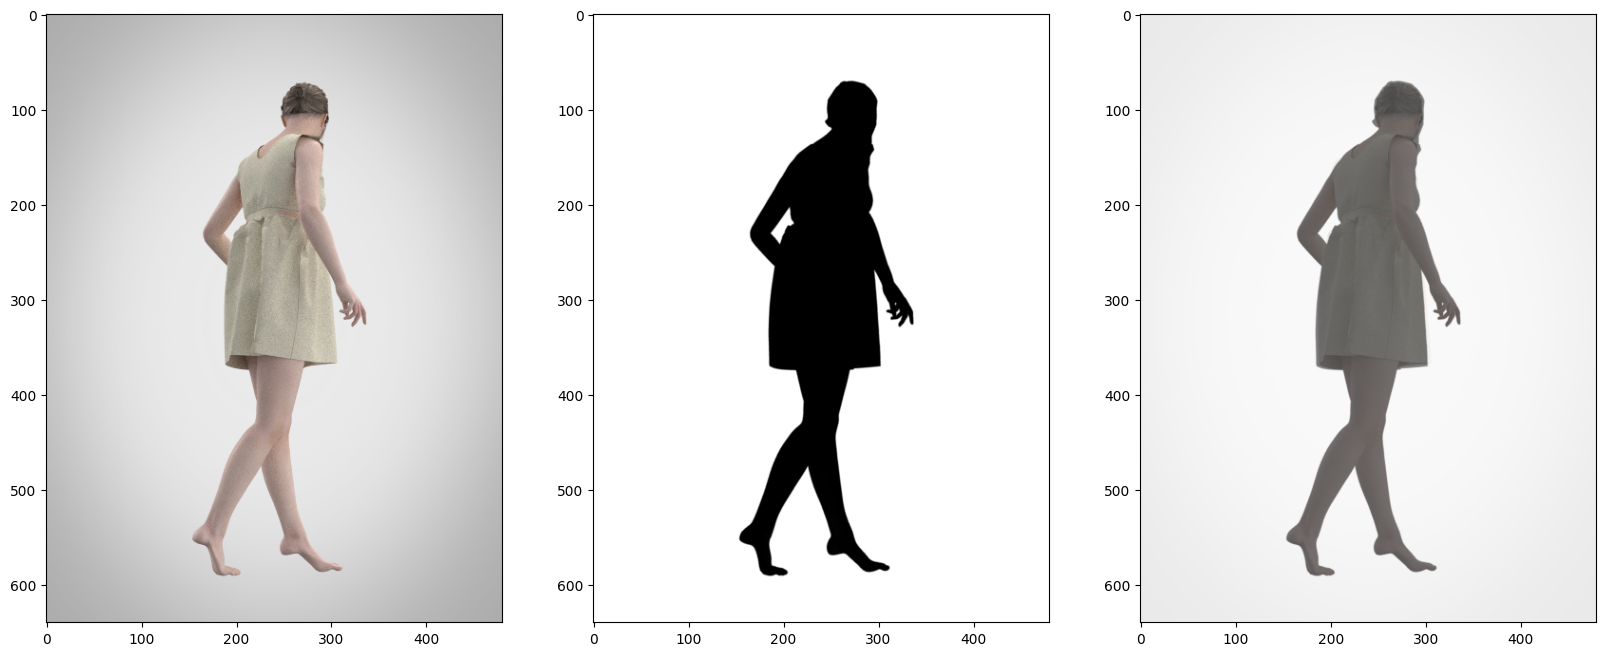

0 wb_dress_sleeveless_H097SG0SIZ


/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/wb_dress_sleeveless_H097SG0SIZ__01/random__Custom_View_5_1.png


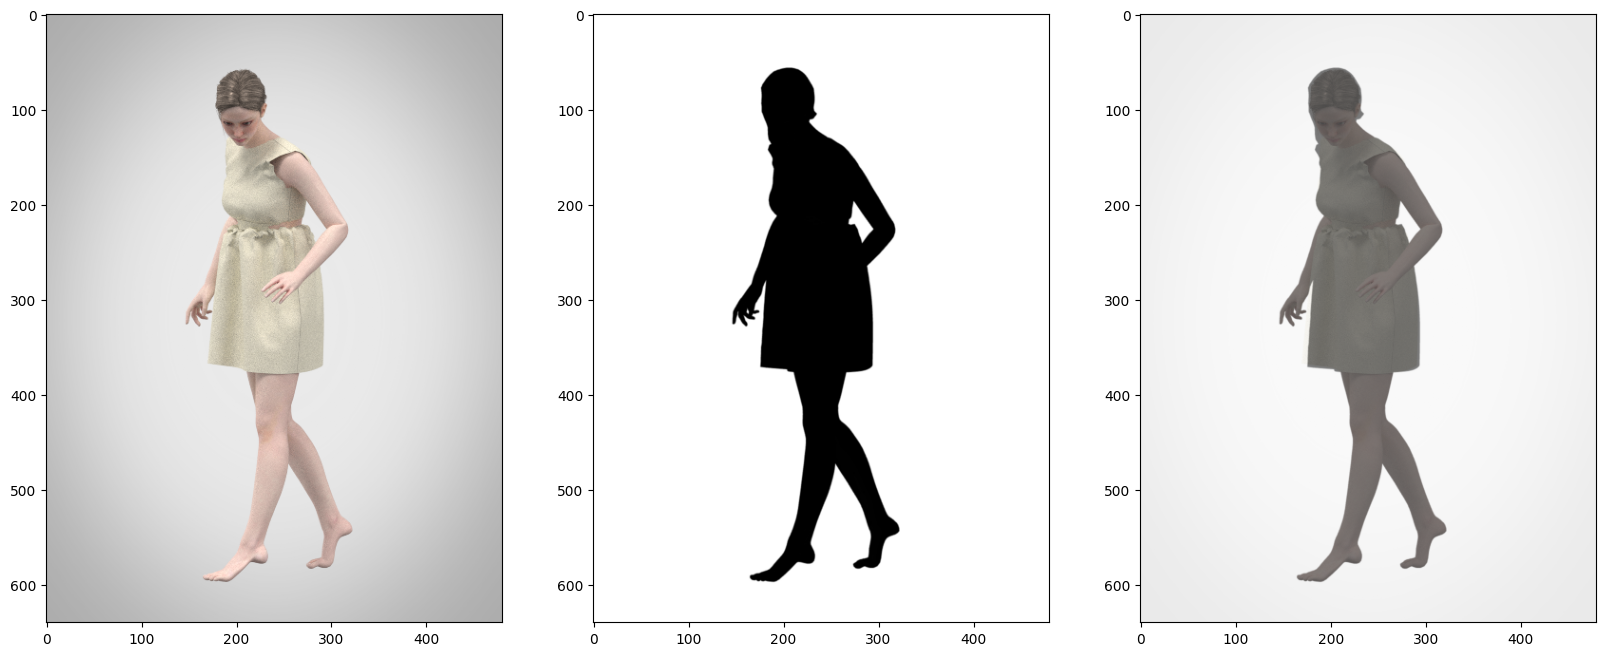

0 wb_dress_sleeveless_H097SG0SIZ


/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/wb_dress_sleeveless_H097SG0SIZ__01/Dynamic__Custom_View_6_1.png


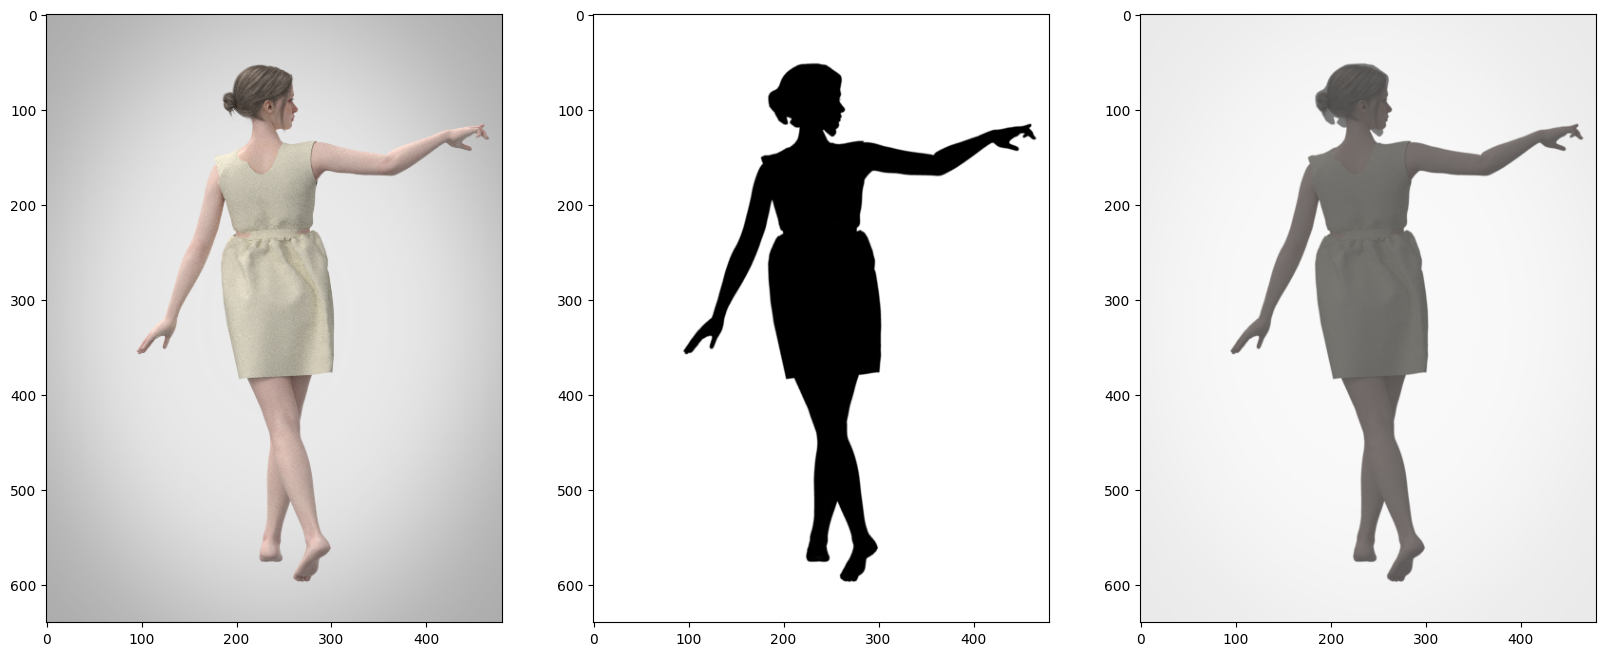

0 wb_dress_sleeveless_H097SG0SIZ


/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/wb_dress_sleeveless_H097SG0SIZ__01/FV2_05__Custom_View_7_1.png


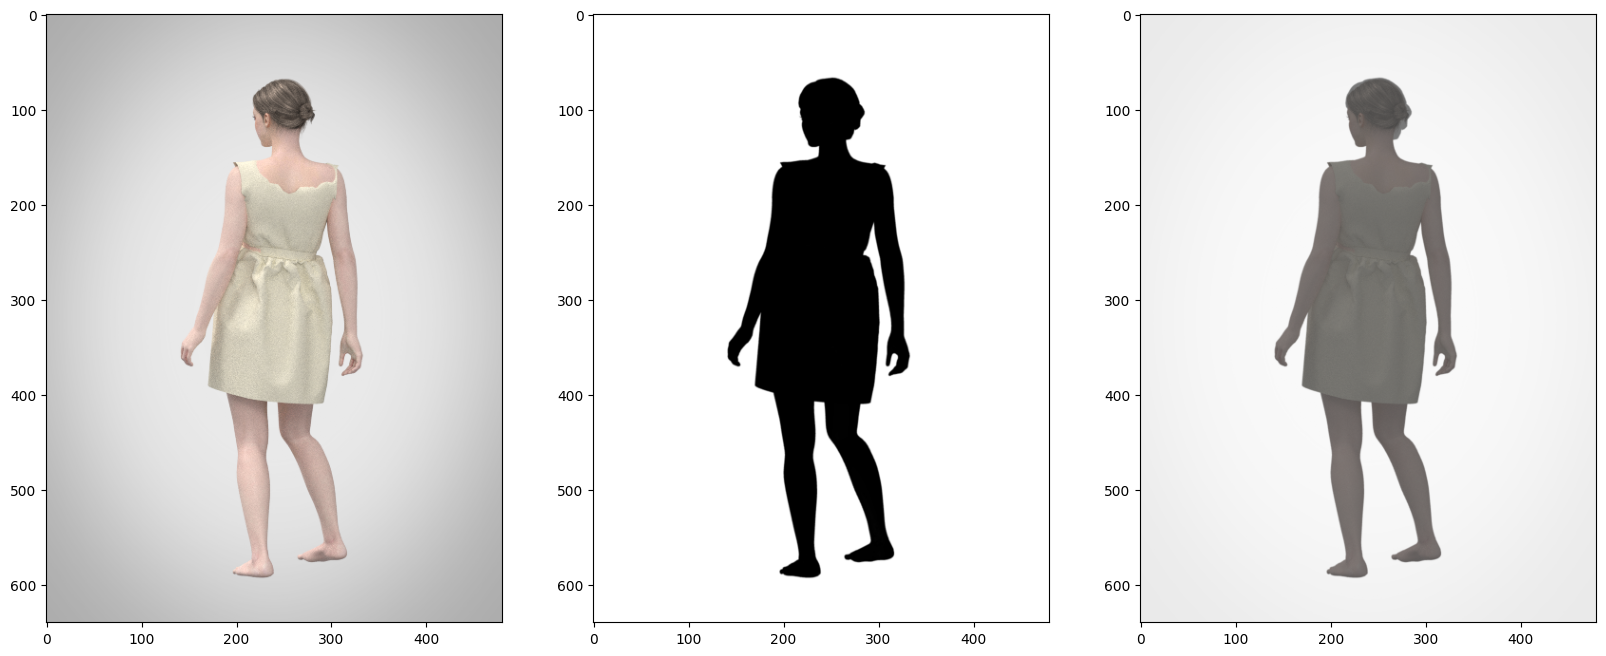

0 wb_dress_sleeveless_H097SG0SIZ


/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/wb_dress_sleeveless_H097SG0SIZ__01/random__Custom_View_8_1.png


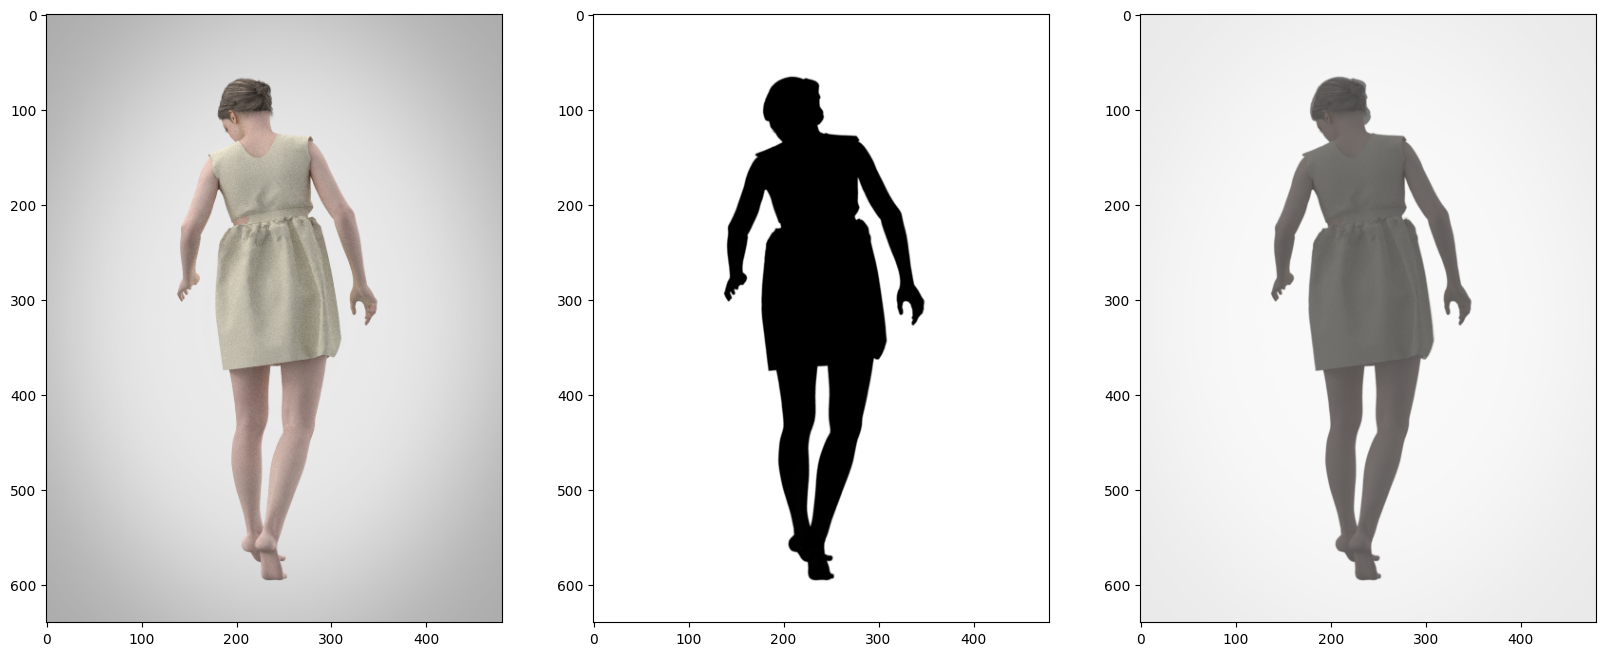

0 wb_dress_sleeveless_H097SG0SIZ


/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/wb_dress_sleeveless_H097SG0SIZ__01/random__Custom_View_9_1.png


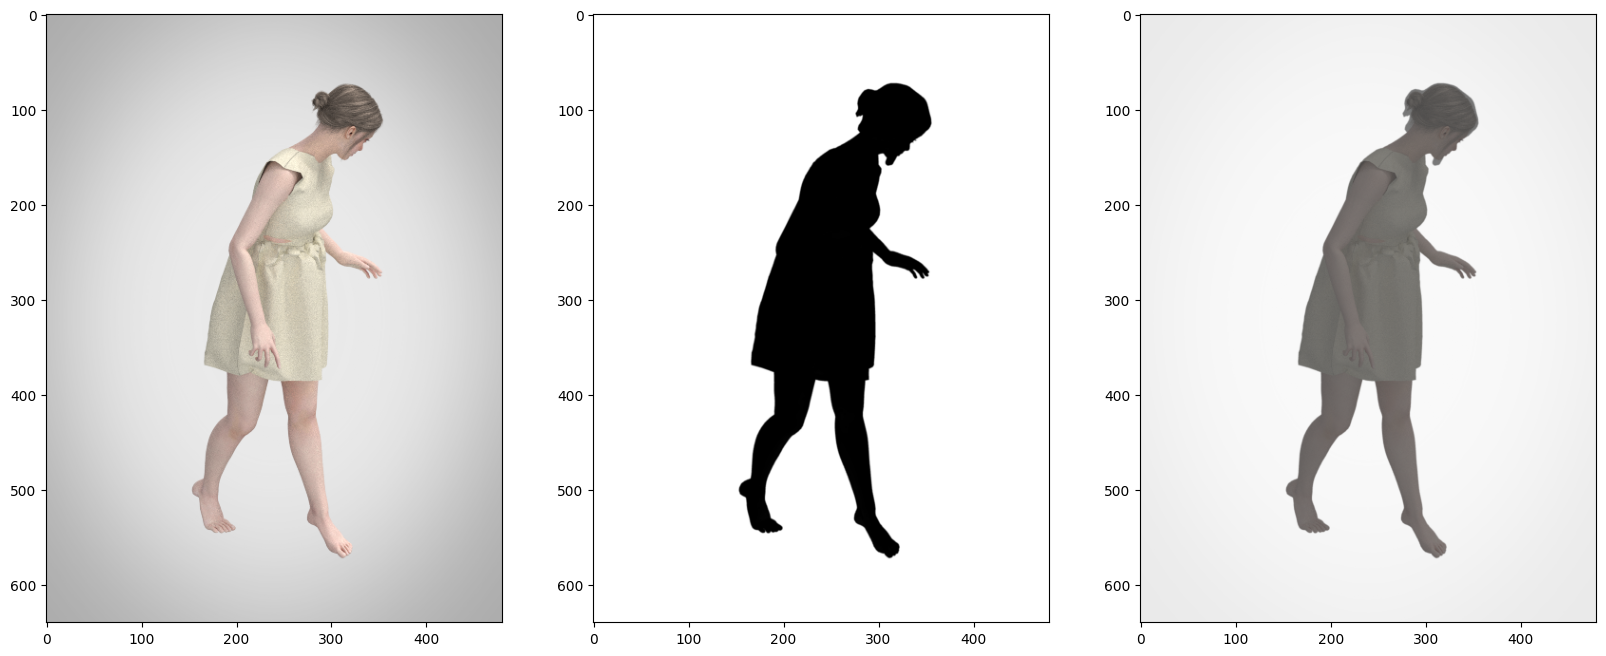

0 wb_dress_sleeveless_H097SG0SIZ


/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/wb_dress_sleeveless_H097SG0SIZ__01/Dynamic_2__Custom_View_10_1.png


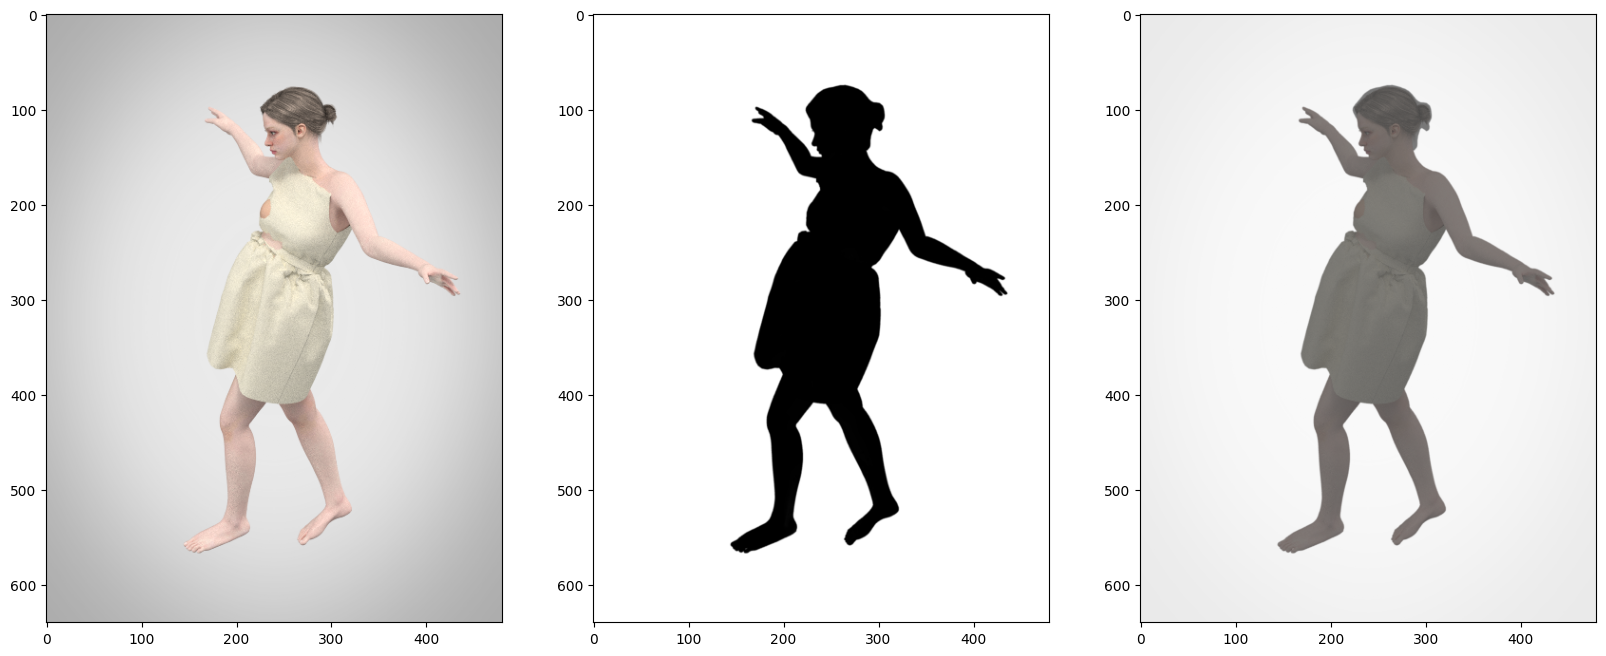

0 wb_dress_sleeveless_H097SG0SIZ




In [8]:
import pyrender

VIS = True
MIN_CONSEC_VERT_TO_BE_SEGMENT = 3
MIN_CONSEC_VERT_TO_DISCONNECT = 2

for rendered_img_path in scene.rendered_path_list :
    
    print(rendered_img_path)
    
    pose_name, cam_name = Path(rendered_img_path).stem.split("__")
    cam_name = "_".join(cam_name.split("_")[:-1])
    
    cam_info = camera_info[cam_name]

    body_mesh = scene.body_mesh_dict[pose_name]
    garment_mesh_dict = scene.garment_mesh_dict_dict[pose_name]
    garment_mesh_list = list(garment_mesh_dict.values())

    if VIS :
        plt.figure(figsize=(20, 10))
        ax = plt.subplot(1, 3, 1)
        ax.imshow(plt.imread(rendered_img_path))
        
    material = pyrender.MetallicRoughnessMaterial(
        baseColorFactor=(0.0, 0.0, 0.0, 1.0),  # RGB color, Alpha
        metallicFactor=0.658,  # Range: [0.0, 1.0]
        roughnessFactor=0.5  # Range: [0.0, 1.0]
    )
    
    pyrender_body_mesh = pyrender.Mesh.from_trimesh(
        body_mesh, material=material
    )
    
    pyrender_garment_mesh_list = [pyrender.Mesh.from_trimesh(
        garment_mesh, material=material
    ) for garment_mesh in garment_mesh_list]
    
    
    pyrender_cam = pyrender.PerspectiveCamera(
        yfov = np.deg2rad(cam_info.fov),
    )
    
    pyrender_scene = pyrender.Scene(bg_color=(1.0, 1.0, 1.0, 1.0))
    
    pyrender_scene.add(pyrender_body_mesh)
    
    for pyrender_garment_mesh in pyrender_garment_mesh_list :
        pyrender_scene.add(pyrender_garment_mesh)
    pyrender_scene.add(pyrender_cam, pose=cam_info.cam2world)
    
    camera_node = list(filter(
        lambda x : x.camera is not None,
        pyrender_scene.get_nodes()
    ))[-1]
    
    
    intensity = 80.
    light_positions = [
        np.array([1.60614, 1.5341, 1.23701]),
        np.array([1.31844, 1.92831, -2.52238]),
        np.array([-2.80522, 1.2594, 2.34624]),
        np.array([0.160261, 1.81789, 3.52215]),
        np.array([-2.65752, 1.41194, -1.26328])
    ]
    light_colors = [
        [1.0, 1.0, 1.0],
        [1.0, 1.0, 1.0],
        [1.0, 1.0, 1.0],
        [1.0, 1.0, 1.0],
        [1.0, 1.0, 1.0]
    ]

    for i in range(5):
        light = pyrender.PointLight(color=light_colors[i], intensity=intensity)
        light_pose = np.eye(4)
        light_pose[:3, 3] = light_positions[i]
        pyrender_scene.add(light, pose=light_pose)

    try :    
        r = pyrender.OffscreenRenderer(
            viewport_width=cam_info.width, viewport_height=cam_info.height
        )
        flags = pyrender.RenderFlags.SKIP_CULL_FACES
        color, depth = r.render(pyrender_scene, flags=flags)
        r.delete()

    except Exception as e :
        print(e)
        continue
    
    if VIS :
        
        ax = plt.subplot(1, 3, 2)
        ax.imshow(color)
        
        ax = plt.subplot(1, 3, 3)
        ax.imshow(plt.imread(rendered_img_path), alpha=0.5)
        ax.imshow(color, alpha=0.5)
        
    width, height = cam_info.width, cam_info.height
    view_matrix = np.linalg.inv(pyrender_scene.get_pose(camera_node))
    proj_matrix = camera_node.camera.get_projection_matrix(width, height)
    
    visibility_mask_list = []
    pixel_coords_list = []
    for garment_mesh in garment_mesh_list :
        vertices_homog = np.hstack([
            garment_mesh.vertices,
            np.ones((garment_mesh.vertices.shape[0], 1))
        ])

        view_proj = proj_matrix @ view_matrix
        projected = vertices_homog @ view_proj.T

        z_coords = projected[:, 2].copy()
        projected = projected[:, :3] / projected[:, 3:4]

        pixel_coords = np.zeros((projected.shape[0], 2))
        pixel_coords[:, 0] = (projected[:, 0] + 1.0) * width / 2.0
        pixel_coords[:, 1] = height - (projected[:, 1] + 1.0) * height / 2.0

        px = np.clip(pixel_coords[:, 0].astype(int), 0, width - 1)
        py = np.clip(pixel_coords[:, 1].astype(int), 0, height - 1)

        THRESHOLD = -0.5
        THRESHOLD = -80.
        visibility_mask = (
            z_coords > 0
        ) &  (
            pixel_coords[:, 0] >= 0
        ) & (
            pixel_coords[:, 0] < width
        ) & (
            pixel_coords[:, 1] >= 0
        ) & (
            pixel_coords[:, 1] < height
        ) & (
            z_coords + THRESHOLD <= depth[py, px]
        )
        
        visibility_mask_list.append(visibility_mask)
        pixel_coords_list.append(pixel_coords)
        
        if VIS :
            vis_img = np.zeros((height, width), dtype=np.uint8)
            vis_img[
                pixel_coords[visibility_mask][:, 1].astype(int),
                pixel_coords[visibility_mask][:, 0].astype(int)
            ] = 255
            # plt.imshow(vis_img, cmap="gray")
            plt.show()
        
    if VIS : pass
        # fig = visualize_meshes_plotly(
        #     garment_mesh_list,
        #     vertices_list = list(map(
        #         lambda mesh, vis_mask : mesh.vertices[vis_mask],
        #         garment_mesh_list,
        #         visibility_mask_list
        #     )),
        #     vertices_color_list=["red"] * len(garment_mesh_list),
        #     show_edges=True,
        #     show = False
        # )
        # fig.show()
        
        
        
    visible_seam_line_dict_dict = {}
    
    for idx, garment_id in enumerate(scene.stitch_dict_dict.keys()) :
        visible_seam_line_dict_dict[garment_id] = {}
        
        print(idx, garment_id)
        garment_mesh = garment_mesh_dict[garment_id]
        vert_count = garment_mesh.vertices.shape[0]
        
        stitch_dict = scene.stitch_dict_dict[garment_id]
        seam_line_vert_idx_arr_dict = scene.seam_line_vert_idx_arr_dict_dict[garment_id]
        
        visibility_mask = visibility_mask_list[idx]
        pixel_coords = pixel_coords_list[idx]
        
        for stch_idx, seam_line_vert_idx_arr in seam_line_vert_idx_arr_dict.items() :
            seam_line_vert_idx_arr = np.array(seam_line_vert_idx_arr)
            
            seam_line_vis_mask = []
            for seam_vert_idx in seam_line_vert_idx_arr :
                seam_line_vis_mask.append(visibility_mask[seam_vert_idx])
            seam_line_vis_mask = np.array(seam_line_vis_mask)
                
            # If length of disconnection between visible seam vertices
            # is less then MIN_CONSEC_VERT_TO_DISCONNECT,
            # consider the disconnection is connected
            # (which change invisible seam vertices to visible)
            idx = 0
            while idx < len(seam_line_vis_mask) :
                if idx >= len(seam_line_vis_mask) -2 :
                    break

                while not (seam_line_vis_mask[idx] == True and seam_line_vis_mask[idx + 1] == False) :
                    if idx >= len(seam_line_vis_mask) - 2 :
                        break
                    idx += 1
                if idx >= len(seam_line_vis_mask) - 2 :
                    break
                window_end_idx = min(idx + MIN_CONSEC_VERT_TO_DISCONNECT + 1, len(seam_line_vis_mask) - 1)
                for rid in range(window_end_idx, idx, -1) :
                    if seam_line_vis_mask[rid] == True :
                        seam_line_vis_mask[idx:rid] = True
                        break
                idx = rid
            

            # If length of connection between visible seam vertices
            # is less then MIN_CONSEC_VERT_TO_BE_SEGMENT,
            # consider the connection is not a segment
            # (which change visible seam vertices to invisible)
            idx = 0
            while idx < len(seam_line_vis_mask) :
                if seam_line_vis_mask[idx] != True :
                    idx += 1
                    continue
                idx2 = idx + 1
                while idx2 < len(seam_line_vis_mask) and seam_line_vis_mask[idx2] == True :
                    idx2 += 1
                if idx2 - idx < MIN_CONSEC_VERT_TO_BE_SEGMENT :
                    seam_line_vis_mask[idx:idx2] = False
                idx = idx2
                
            line_segment_idx_arr_list = []
            line_segment_pos_arr_list = []
            if True in seam_line_vis_mask :
                idx = seam_line_vis_mask.tolist().index(True)
                while idx < len(seam_line_vis_mask) :
                    line_segment_idx_list = []
                    line_segment_pos_list = []
                    while idx < len(seam_line_vis_mask) and seam_line_vis_mask[idx] == True :
                        line_segment_idx_list.append(
                            seam_line_vert_idx_arr[idx]
                        )
                        line_segment_pos_list.append(
                            pixel_coords[seam_line_vert_idx_arr[idx]]
                        )
                        idx += 1
                    if len(line_segment_idx_list) > 0 :
                        line_segment_idx_arr_list.append(np.array(line_segment_idx_list))
                        line_segment_pos_arr_list.append(np.array(line_segment_pos_list))
                    idx += 1

            if len(line_segment_pos_arr_list) > 0 :
                segment_edge_len_arr_list = []
                segment_t_arr_list = []
                segment_u_arr_list = []
                segment_v_arr_list = []
                for segment_pos_arr in line_segment_pos_arr_list :
                    i_vec = segment_pos_arr[-1] - segment_pos_arr[0]
                    j_vec = np.array([i_vec[1], -i_vec[0]])
                    
                    i_vec_normalized = i_vec / np.linalg.norm(i_vec)
                    j_vec_normalized = j_vec / np.linalg.norm(j_vec)
                    
                    edge_len_arr = np.concatenate((
                        [0],
                        np.linalg.norm(segment_pos_arr[1:] - segment_pos_arr[:-1], axis=1)
                    ))
                    segment_edge_len_arr_list.append(edge_len_arr)
                    t_arr = np.cumsum(edge_len_arr) / np.sum(edge_len_arr)
                    
                    vect_arr = segment_pos_arr - segment_pos_arr[0]
                    u_arr = np.sum(vect_arr * i_vec_normalized, axis=1) / np.linalg.norm(i_vec)
                    v_arr = np.sum(vect_arr * j_vec_normalized, axis=1) / np.linalg.norm(j_vec)
                    
                    segment_t_arr_list.append(t_arr)
                    segment_u_arr_list.append(u_arr)
                    segment_v_arr_list.append(v_arr)
                
                    
                    if len(t_arr) != len(segment_pos_arr) :
                        print(segment_pos_arr.shape, t_arr.shape, u_arr.shape, v_arr.shape)
                        print("error")
                    
                    
                    if len(t_arr) != len(u_arr) or len(t_arr) != len(v_arr) :
                        print(edge_len_arr.shape, t_arr.shape, u_arr.shape, v_arr.shape)
                        print("error")
                    
                    error_num = np.sum(
                        vect_arr - (u_arr.reshape(-1, 1) * i_vec.reshape(1, -1) + v_arr.reshape(-1, 1) * j_vec.reshape(1, -1))
                    )
                    if error_num > 1e-6 :
                        print(vect_arr.shape, u_arr.shape, v_arr.shape)
                        print(error_num)
                        print("error")

                visible_seam_line_dict_dict[garment_id][stch_idx] = {
                    "segment_idx_arr_list" : line_segment_idx_arr_list,
                    "segment_pos_arr_list" : line_segment_pos_arr_list,
                    "segment_edge_len_arr_list" : segment_edge_len_arr_list,
                    "segment_t_arr_list" : segment_t_arr_list,
                    "segment_u_arr_list" : segment_u_arr_list,
                    "segment_v_arr_list" : segment_v_arr_list
                }

    print()
    print()

In [17]:
color.dtype, color.shape, depth.shape, depth.dtype

(dtype('uint8'), (640, 480, 3), (640, 480), dtype('float32'))

In [51]:
from PIL import Image
img = np.array(Image.open(scene.rendered_path_list[-1]))

img[:, :, 3] = (depth != 0) * 255

# Convert numpy array back to PIL Image and save
img_pil = Image.fromarray(img.astype('uint8'))
img_pil.save('output_image.png')

In [53]:
os.path.basename(rendered_img_path)

'Dynamic_2__Custom_View_10_1.png'

In [54]:
os.path.dirname(rendered_img_path)

'/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/wb_dress_sleeveless_H097SG0SIZ__01'

In [55]:
garment_path_list

['/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/dress_sleeveless_45V6ZGELXG__01',
 '/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/dress_sleeveless_4R3PV1G9I0__01',
 '/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/wb_dress_sleeveless_H097SG0SIZ__01',
 '/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/dress_sleeveless_4EI7RB9464__01',
 '/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/rand_PMC1DC5RA8__01__rand_HPZQ55OXXC__01',
 '/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/dress_sleeveless_005CWF73E9__01',
 '/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/dress_sleeveless_4JILJHEVIR__01',
 '/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN/sample_data/dress_sleeveless_48R3G5YQID__01']

In [8]:
import pyrender
import trimesh
from PIL import Image
import pickle


MIN_CONSEC_VERT_TO_BE_SEGMENT = 3
MIN_CONSEC_VERT_TO_DISCONNECT = 2

VIS = False

for garment_path in garment_path_list :
    scene = SeamDressScene(base_path=Path(garment_path))
    scene.read_mesh()

    for rendered_img_path in scene.rendered_path_list :
        
        pose_name, cam_name = Path(rendered_img_path).stem.split("__")
        cam_name = "_".join(cam_name.split("_")[:-1])
        
        cam_info = camera_info[cam_name]

        body_mesh = scene.body_mesh_dict[pose_name]
        garment_mesh_dict = scene.garment_mesh_dict_dict[pose_name]
        garment_mesh_list = list(garment_mesh_dict.values())

        if VIS :
            plt.imshow(plt.imread(rendered_img_path))
            plt.show()
            
        material = pyrender.MetallicRoughnessMaterial(
            baseColorFactor=(0.0, 0.0, 0.0, 1.0),  # RGB color, Alpha
            metallicFactor=0.658,  # Range: [0.0, 1.0]
            roughnessFactor=0.5  # Range: [0.0, 1.0]
        )
        
        pyrender_body_mesh = pyrender.Mesh.from_trimesh(
            body_mesh, material=material
        )
        
        pyrender_garment_mesh_list = [pyrender.Mesh.from_trimesh(
            garment_mesh, material=material
        ) for garment_mesh in garment_mesh_list]
        
        
        pyrender_cam = pyrender.PerspectiveCamera(
            yfov = np.deg2rad(cam_info.fov),
        )
        
        pyrender_scene = pyrender.Scene(bg_color=(1.0, 1.0, 1.0, 1.0))
        
        pyrender_scene.add(pyrender_body_mesh)
        
        for pyrender_garment_mesh in pyrender_garment_mesh_list :
            pyrender_scene.add(pyrender_garment_mesh)
        pyrender_scene.add(pyrender_cam, pose=cam_info.cam2world)
        
        camera_node = list(filter(
            lambda x : x.camera is not None,
            pyrender_scene.get_nodes()
        ))[-1]
        
        
        intensity = 80.
        light_positions = [
            np.array([1.60614, 1.5341, 1.23701]),
            np.array([1.31844, 1.92831, -2.52238]),
            np.array([-2.80522, 1.2594, 2.34624]),
            np.array([0.160261, 1.81789, 3.52215]),
            np.array([-2.65752, 1.41194, -1.26328])
        ]
        light_colors = [
            [1.0, 1.0, 1.0],
            [1.0, 1.0, 1.0],
            [1.0, 1.0, 1.0],
            [1.0, 1.0, 1.0],
            [1.0, 1.0, 1.0]
        ]

        for i in range(5):
            light = pyrender.PointLight(color=light_colors[i], intensity=intensity)
            light_pose = np.eye(4)
            light_pose[:3, 3] = light_positions[i]
            pyrender_scene.add(light, pose=light_pose)

        try :    
            r = pyrender.OffscreenRenderer(
                viewport_width=cam_info.width, viewport_height=cam_info.height
            )
            flags = pyrender.RenderFlags.SKIP_CULL_FACES
            color, depth = r.render(pyrender_scene, flags=flags)
            r.delete()


            # save background removed image
            img = np.array(Image.open(rendered_img_path))
            img[:, :, 3] = (depth != 0) * 255
            img_pil = Image.fromarray(img.astype('uint8'))
            img_pil.save(os.path.join(
                os.path.dirname(rendered_img_path),
                f"WB__{os.path.basename(rendered_img_path)}"
            ))

        except Exception as e :
            print(e)
            continue
        
        if VIS :
            plt.imshow(color)
            plt.show()
            
            plt.imshow(plt.imread(rendered_img_path), alpha=0.5)
            plt.imshow(color, alpha=0.5)
            plt.show()
            
        width, height = cam_info.width, cam_info.height
        view_matrix = np.linalg.inv(pyrender_scene.get_pose(camera_node))
        proj_matrix = camera_node.camera.get_projection_matrix(width, height)
        
        visibility_mask_list = []
        pixel_coords_list = []
        for garment_mesh in garment_mesh_list :
            vertices_homog = np.hstack([
                garment_mesh.vertices,
                np.ones((garment_mesh.vertices.shape[0], 1))
            ])

            view_proj = proj_matrix @ view_matrix
            projected = vertices_homog @ view_proj.T

            z_coords = projected[:, 2].copy()
            projected = projected[:, :3] / projected[:, 3:4]

            pixel_coords = np.zeros((projected.shape[0], 2))
            pixel_coords[:, 0] = (projected[:, 0] + 1.0) * width / 2.0
            pixel_coords[:, 1] = height - (projected[:, 1] + 1.0) * height / 2.0

            px = np.clip(pixel_coords[:, 0].astype(int), 0, width - 1)
            py = np.clip(pixel_coords[:, 1].astype(int), 0, height - 1)

            THRESHOLD = -0.5
            THRESHOLD = -80.
            visibility_mask = (
                z_coords > 0
            ) &  (
                pixel_coords[:, 0] >= 0
            ) & (
                pixel_coords[:, 0] < width
            ) & (
                pixel_coords[:, 1] >= 0
            ) & (
                pixel_coords[:, 1] < height
            ) & (
                z_coords + THRESHOLD <= depth[py, px]
            )
            
            visibility_mask_list.append(visibility_mask)
            pixel_coords_list.append(pixel_coords)
            
            if VIS :
                vis_img = np.zeros((height, width), dtype=np.uint8)
                vis_img[
                    pixel_coords[visibility_mask][:, 1].astype(int),
                    pixel_coords[visibility_mask][:, 0].astype(int)
                ] = 255
                plt.imshow(vis_img, cmap="gray")
                plt.show()
            
        if VIS :
            fig = visualize_meshes_plotly(
                garment_mesh_list,
                vertices_list = list(map(
                    lambda mesh, vis_mask : mesh.vertices[vis_mask],
                    garment_mesh_list,
                    visibility_mask_list
                )),
                vertices_color_list=["red"] * len(garment_mesh_list),
                show_edges=True,
                show = False
            )
            fig.show()
            
            
            
        visible_seam_line_dict_dict = {}
        
        for idx, garment_id in enumerate(scene.stitch_dict_dict.keys()) :
            visible_seam_line_dict_dict[garment_id] = {}
            
            # print(idx, garment_id)
            garment_mesh = garment_mesh_dict[garment_id]
            vert_count = garment_mesh.vertices.shape[0]
            
            stitch_dict = scene.stitch_dict_dict[garment_id]
            seam_line_vert_idx_arr_dict = scene.seam_line_vert_idx_arr_dict_dict[garment_id]
            
            visibility_mask = visibility_mask_list[idx]
            pixel_coords = pixel_coords_list[idx]
            
            for stch_idx, seam_line_vert_idx_arr in seam_line_vert_idx_arr_dict.items() :
                seam_line_vert_idx_arr = np.array(seam_line_vert_idx_arr)
                
                seam_line_vis_mask = []
                for seam_vert_idx in seam_line_vert_idx_arr :
                    seam_line_vis_mask.append(visibility_mask[seam_vert_idx])
                seam_line_vis_mask = np.array(seam_line_vis_mask)
                    
                # If length of disconnection between visible seam vertices
                # is less then MIN_CONSEC_VERT_TO_DISCONNECT,
                # consider the disconnection is connected
                # (which change invisible seam vertices to visible)
                idx = 0
                while idx < len(seam_line_vis_mask) :
                    if idx >= len(seam_line_vis_mask) -2 :
                        break

                    while not (seam_line_vis_mask[idx] == True and seam_line_vis_mask[idx + 1] == False) :
                        if idx >= len(seam_line_vis_mask) - 2 :
                            break
                        idx += 1
                    if idx >= len(seam_line_vis_mask) - 2 :
                        break
                    window_end_idx = min(idx + MIN_CONSEC_VERT_TO_DISCONNECT + 1, len(seam_line_vis_mask) - 1)
                    for rid in range(window_end_idx, idx, -1) :
                        if seam_line_vis_mask[rid] == True :
                            seam_line_vis_mask[idx:rid] = True
                            break
                    idx = rid
                

                # If length of connection between visible seam vertices
                # is less then MIN_CONSEC_VERT_TO_BE_SEGMENT,
                # consider the connection is not a segment
                # (which change visible seam vertices to invisible)
                idx = 0
                while idx < len(seam_line_vis_mask) :
                    if seam_line_vis_mask[idx] != True :
                        idx += 1
                        continue
                    idx2 = idx + 1
                    while idx2 < len(seam_line_vis_mask) and seam_line_vis_mask[idx2] == True :
                        idx2 += 1
                    if idx2 - idx < MIN_CONSEC_VERT_TO_BE_SEGMENT :
                        seam_line_vis_mask[idx:idx2] = False
                    idx = idx2
                    
                line_segment_idx_arr_list = []
                line_segment_pos_arr_list = []
                if True in seam_line_vis_mask :
                    idx = seam_line_vis_mask.tolist().index(True)
                    while idx < len(seam_line_vis_mask) :
                        line_segment_idx_list = []
                        line_segment_pos_list = []
                        while idx < len(seam_line_vis_mask) and seam_line_vis_mask[idx] == True :
                            line_segment_idx_list.append(
                                seam_line_vert_idx_arr[idx]
                            )
                            line_segment_pos_list.append(
                                pixel_coords[seam_line_vert_idx_arr[idx]]
                            )
                            idx += 1
                        if len(line_segment_idx_list) > 0 :
                            line_segment_idx_arr_list.append(np.array(line_segment_idx_list))
                            line_segment_pos_arr_list.append(np.array(line_segment_pos_list))
                        idx += 1

                if len(line_segment_pos_arr_list) > 0 :
                    segment_edge_len_arr_list = []
                    segment_t_arr_list = []
                    segment_u_arr_list = []
                    segment_v_arr_list = []
                    for segment_pos_arr in line_segment_pos_arr_list :
                        i_vec = segment_pos_arr[-1] - segment_pos_arr[0]
                        j_vec = np.array([i_vec[1], -i_vec[0]])
                        
                        i_vec_normalized = i_vec / np.linalg.norm(i_vec)
                        j_vec_normalized = j_vec / np.linalg.norm(j_vec)
                        
                        edge_len_arr = np.concatenate((
                            [0],
                            np.linalg.norm(segment_pos_arr[1:] - segment_pos_arr[:-1], axis=1)
                        ))
                        segment_edge_len_arr_list.append(edge_len_arr)
                        t_arr = np.cumsum(edge_len_arr) / np.sum(edge_len_arr)
                        
                        vect_arr = segment_pos_arr - segment_pos_arr[0]
                        u_arr = np.sum(vect_arr * i_vec_normalized, axis=1) / np.linalg.norm(i_vec)
                        v_arr = np.sum(vect_arr * j_vec_normalized, axis=1) / np.linalg.norm(j_vec)
                        
                        segment_t_arr_list.append(t_arr)
                        segment_u_arr_list.append(u_arr)
                        segment_v_arr_list.append(v_arr)
                    
                        
                        if len(t_arr) != len(segment_pos_arr) :
                            print(segment_pos_arr.shape, t_arr.shape, u_arr.shape, v_arr.shape)
                            print("error")
                        
                        
                        if len(t_arr) != len(u_arr) or len(t_arr) != len(v_arr) :
                            print(edge_len_arr.shape, t_arr.shape, u_arr.shape, v_arr.shape)
                            print("error")
                        
                        error_num = np.sum(
                            vect_arr - (u_arr.reshape(-1, 1) * i_vec.reshape(1, -1) + v_arr.reshape(-1, 1) * j_vec.reshape(1, -1))
                        )
                        if error_num > 1e-6 :
                            print(vect_arr.shape, u_arr.shape, v_arr.shape)
                            print(error_num)
                            print("error")

                    visible_seam_line_dict_dict[garment_id][stch_idx] = {
                        "segment_idx_arr_list" : line_segment_idx_arr_list,
                        "segment_pos_arr_list" : line_segment_pos_arr_list,
                        "segment_edge_len_arr_list" : segment_edge_len_arr_list,
                        "segment_t_arr_list" : segment_t_arr_list,
                        "segment_u_arr_list" : segment_u_arr_list,
                        "segment_v_arr_list" : segment_v_arr_list
                    }
            
        # print(rendered_img_path)
        # print(os.path.splitext(rendered_img_path)[0])
        
        with open(
            f"{os.path.splitext(rendered_img_path)[0]}_seam_line.pkl",
            "wb"
        ) as fp:
            pickle.dump(visible_seam_line_dict_dict, fp)

ObjCInstance b'PygletDelegate' has no attribute b'initWithAttributes_'
ObjCInstance b'PygletDelegate' has no attribute b'initWithAttributes_'
ObjCInstance b'PygletDelegate' has no attribute b'initWithAttributes_'
ObjCInstance b'PygletDelegate' has no attribute b'initWithAttributes_'


In [9]:

MIN_CONSEC_VERT_TO_BE_SEGMENT = 3
# Connect Disconnected vertices, if length of disconnected vertices <= MIN_CONSEC_VERT_TO_DISCONNECT
MIN_CONSEC_VERT_TO_DISCONNECT = 2
    


In [10]:
SPEC_ID = 0

pattern = pyg.pattern.wrappers.VisPattern(scene.spec_path_list[SPEC_ID])

panel_svg_path_dict = {
    panel_name : pattern._draw_a_panel(
        panel_name, apply_transform=False, fill=True
    )
    for panel_name in pattern.panel_order()
}
stitch_dict = {
    i : v for i, v in enumerate(pattern.pattern['stitches'])
}

sewing_pattern = SewingPattern(panel_svg_path_dict, stitch_dict)

# sewing_pattern.draw(
#     # plot_panel_name = False,
#     # plot_stitch_name = False
# )






In [11]:
stitch_vert_idx_list = []
for stitch_idx in scene.stitch_dict_list[SPEC_ID].keys() :
    stitch_vert_idx_list.append(
        np.array(scene.stitch_vert_idx_list_list[stitch_idx])
    )
    
vert_count = garment_mesh.vertices.shape[0]

stitch_vert_mask_dict = dict()

for idx, stitch_vert_arr in enumerate(stitch_vert_idx_list) :
    stitch_vert_mask_dict[idx] = np.zeros(vert_count, dtype=bool)
    stitch_vert_mask_dict[idx][stitch_vert_arr] = True
    